# What point, line, and footprint sensors observe

Write y=Ax+ε. Each row of A describes support. Line quadrature computes an average rather than treating a measurement as a midpoint value. The adjoint spreads residuals to their supports; it does not invert A.

**Objective:** verify conservation of constants and understand an adjoint.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


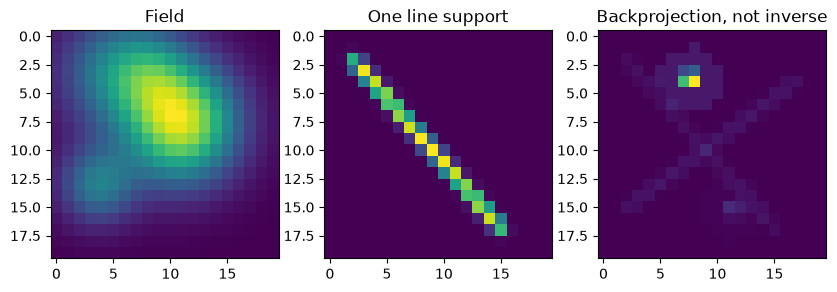

Measurements: [0.82247678 0.09568374 0.42067661 0.52925907 0.75255436 0.11664904]


In [2]:
grid=Grid((20,20)); f=simulate(grid,3)
p=np.array([[.2,.4],[.8,.6]])
e=np.array([[[.1,.1],[.9,.8]],[[.2,.9],[.8,.1]]])
A=combine(points(grid,p),lines(grid,e),footprints(grid,p,.15))
assert np.allclose(A@np.ones(grid.size),1)
rng=np.random.default_rng(9); x=rng.normal(size=grid.size); v=rng.normal(size=A.shape[0])
assert np.allclose((A@x)@v,x@(A.T@v))
fig,axes=plt.subplots(1,3,figsize=(10,3))
axes[0].imshow(f); axes[0].set_title('Field')
axes[1].imshow(A[2].reshape(grid.shape)); axes[1].set_title('One line support')
axes[2].imshow((A.T@(A@f.ravel())).reshape(grid.shape)); axes[2].set_title('Backprojection, not inverse')
plt.show()
print('Measurements:',A@f.ravel())


**Exercise:** measure a linear field analytically; a line average equals the mean of its endpoint values. Construct a curved field for which this fails. Compare quadrature with 8 and 128 samples. Check that reversing endpoints preserves an average.

See [theory notes](../docs/theory.md) for assumptions and equations.